# Intelligent Microscopy for Materials

## Notebook 02 — Classical Image-Feature Baseline

### Objective

This notebook establishes a conventional machine-learning baseline for
classification of scanning electron microscopy (SEM) morphology.

The workflow uses the fixed, leakage-controlled train, validation, and test
partitions generated in Notebook 01.

Rather than learning image representations automatically with deep neural
networks, this notebook extracts engineered visual descriptors that quantify
properties such as:

- intensity distribution;
- texture;
- edges;
- local structural patterns;
- image gradients.

These features are then used with classical machine-learning algorithms to
determine how much morphology information can be captured without deep
learning.

The resulting performance provides a reference point for evaluating the
convolutional neural networks and transfer-learning models developed in later
notebooks.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 1. Load the Fixed Dataset Manifests

Notebook 01 produced a deduplicated dataset containing 20,742 SEM images and
assigned every image to a fixed training, validation, or test partition.

These saved manifests are loaded directly rather than recreating the dataset
split.

Using fixed partitions ensures that all subsequent models are evaluated on
exactly the same data.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/"
    "intelligent-microscopy-materials/data/processed"
)

print("Processed-data folder:", OUTPUT_DIR)
print("Folder exists:", OUTPUT_DIR.exists())

if OUTPUT_DIR.exists():
    print("\nAvailable files:")

    for path in sorted(OUTPUT_DIR.iterdir()):
        print("-", path.name)

Processed-data folder: /content/drive/MyDrive/intelligent-microscopy-materials/data/processed
Folder exists: True

Available files:
- final_class_summary.csv
- near_duplicate_exclusions.csv
- sem_deduplicated_index.csv
- sem_split_manifest.csv
- split_class_counts.csv
- split_class_percentages.csv
- test_manifest.csv
- train_manifest.csv
- validation_manifest.csv


### 1.1 Verify the Fixed Partitions

The training, validation, and test manifests generated in Notebook 01 are
loaded from persistent storage.

Before feature extraction begins, their row counts and class labels are
verified against the finalized dataset split:

- Training: 14,519 images
- Validation: 3,111 images
- Test: 3,112 images
- Total: 20,742 images

In [3]:
# Load the fixed dataset manifests

train_df = pd.read_csv(
    OUTPUT_DIR / "train_manifest.csv"
)

val_df = pd.read_csv(
    OUTPUT_DIR / "validation_manifest.csv"
)

test_df = pd.read_csv(
    OUTPUT_DIR / "test_manifest.csv"
)

split_manifest = pd.read_csv(
    OUTPUT_DIR / "sem_split_manifest.csv"
)

print(f"Training images:   {len(train_df)}")
print(f"Validation images: {len(val_df)}")
print(f"Test images:       {len(test_df)}")
print(f"Total images:      {len(split_manifest)}")

print(
    "\nNumber of morphology classes:",
    split_manifest["class"].nunique()
)

Training images:   14519
Validation images: 3111
Test images:       3112
Total images:      20742

Number of morphology classes: 10


In [4]:
# Inspect the manifest structure

print("Manifest columns:")
for column in split_manifest.columns:
    print("-", column)

display(
    split_manifest[
        [
            "class",
            "filename",
            "relative_path",
            "split",
            "colored_overlay_candidate"
        ]
    ].head()
)

Manifest columns:
- class
- filename
- relative_path
- width
- height
- mode
- md5
- phash
- chromatic_fraction
- colored_overlay_candidate
- split


,class,filename,relative_path,split,colored_overlay_candidate
0,Fibres,L9_101598f903952ce5824bb684d6b49b04.jpg,Fibres/L9_101598f903952ce5824bb684d6b49b04.jpg,validation,False
1,Fibres,L9_b3eb41aa88f18cde89c43b63566b6781.jpg,Fibres/L9_b3eb41aa88f18cde89c43b63566b6781.jpg,validation,False
2,Fibres,L9_43f3cd91d2fa7eb39be50038a3ffc3f0.jpg,Fibres/L9_43f3cd91d2fa7eb39be50038a3ffc3f0.jpg,validation,False
3,Fibres,L9_868551a78f03d7f5f119596a961d842d.jpg,Fibres/L9_868551a78f03d7f5f119596a961d842d.jpg,train,False
4,Fibres,L9_e3899d1ae2a773ee9da752bac01ec6d9.jpg,Fibres/L9_e3899d1ae2a773ee9da752bac01ec6d9.jpg,validation,False


## 2. Restore the Raw SEM Images

The persistent manifests define the exact images assigned to the training,
validation, and test sets, but the original SEM image files are not stored
inside the CSV files.

Because Colab runtime storage is temporary, the raw NFFA-EUROPE images are
restored at the beginning of the modelling session.

All ten morphology archives are downloaded and extracted programmatically.
Each archive is deleted immediately after successful extraction to reduce
temporary disk usage.

No dataset auditing or splitting is repeated in this notebook; the fixed
manifests from Notebook 01 remain authoritative.

In [5]:
import tarfile

DATA_ROOT = Path("/content/sem_data")
ARCHIVE_ROOT = Path("/content/sem_archives")

DATA_ROOT.mkdir(parents=True, exist_ok=True)
ARCHIVE_ROOT.mkdir(parents=True, exist_ok=True)

BASE_URL = (
    "https://b2share.eudat.eu/records/"
    "zja8y-53j14/files"
)

DATASET_FILES = {
    "Fibres": "Fibres.tar",
    "Porous_Sponge": "Porous_Sponge.tar",
    "Films_Coated_Surface": "Films_Coated_Surface.tar",
    "Biological": "Biological.tar",
    "Tips": "Tips.tar",
    "Powder": "Powder.tar",
    "Nanowires": "Nanowires.tar",
    "Particles": "Particles.tar",
    "Patterned_surface": "Patterned_surface.tar",
    "MEMS_devices_and_electrodes":
        "MEMS_devices_and_electrodes.tar",
}

print("Dataset restoration environment ready.")

Dataset restoration environment ready.


In [6]:
# Download, extract, and remove each archive sequentially

for folder_name, archive_name in DATASET_FILES.items():

    class_dir = DATA_ROOT / folder_name
    archive_path = ARCHIVE_ROOT / archive_name

    print("\n" + "=" * 70)
    print(f"Class: {folder_name}")

    # Skip if the class is already present
    if class_dir.exists():
        print("Already extracted — skipping.")
        continue

    url = f"{BASE_URL}/{archive_name}?download=1"

    print("Downloading...")

    !wget -q --show-progress -O "$archive_path" "$url"

    if not archive_path.exists() or archive_path.stat().st_size == 0:
        raise RuntimeError(
            f"Download failed for {archive_name}"
        )

    print("Extracting...")

    with tarfile.open(archive_path, "r") as tar:
        tar.extractall(DATA_ROOT)

    if not class_dir.exists():
        raise RuntimeError(
            f"Expected folder was not created: {folder_name}"
        )

    print("Extraction complete.")

    # Delete archive after successful extraction
    archive_path.unlink()

    print("Temporary archive deleted.")

print("\nAll ten morphology classes restored.")


Class: Fibres
Downloading...
/content/sem_archiv 100%[===================>]  77.23M  12.3MB/s    in 6.9s    
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Porous_Sponge
Downloading...


/tmp/ipykernel_515/3798678613.py:30: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_ROOT)


/content/sem_archiv 100%[===================>] 114.02M  19.9MB/s    in 6.4s    
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Films_Coated_Surface
Downloading...
/content/sem_archiv 100%[===================>] 188.48M  18.7MB/s    in 11s     
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Biological
Downloading...
/content/sem_archiv 100%[===================>] 671.22M  25.4MB/s    in 37s     
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Tips
Downloading...
/content/sem_archiv 100%[===================>] 674.57M  13.7MB/s    in 32s     
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Powder
Downloading...
/content/sem_archiv 100%[===================>] 825.71M  21.2MB/s    in 41s     
Extracting...
Extraction complete.
Temporary archive deleted.

Class: Nanowires
Downloading...
/content/sem_archiv 100%[===================>]   2.05G  16.3MB/s    in 2m 10s  
Extracting...
Extraction complete.
Tempor

### 2.1 Dataset Restoration Verification

The restored image folders are checked against the fixed modelling manifest.

Every relative path referenced by the 20,742-image manifest must resolve to
an existing SEM image before feature extraction begins.

In [7]:
# Verify that every image required by the fixed manifest exists

split_manifest["runtime_path"] = (
    split_manifest["relative_path"]
    .apply(lambda p: str(DATA_ROOT / p))
)

exists_mask = (
    split_manifest["runtime_path"]
    .apply(lambda p: Path(p).exists())
)

print(f"Manifest images: {len(split_manifest)}")
print(f"Images found: {exists_mask.sum()}")
print(f"Missing images: {(~exists_mask).sum()}")

Manifest images: 20742
Images found: 20742
Missing images: 0


## 3. Classical Image-Feature Extraction

Classical machine-learning models cannot learn visual representations directly
from raw image pixels in the same way as convolutional neural networks.

Each SEM image is therefore transformed into a numerical feature vector that
describes complementary aspects of morphology.

The feature set used in this notebook includes:

- **intensity statistics** — overall grayscale distribution;
- **gray-level co-occurrence matrix (GLCM) features** — spatial texture;
- **local binary patterns (LBP)** — local microtexture;
- **edge and gradient descriptors** — structural boundaries;
- **histograms of oriented gradients (HOG)** — directional shape and morphology.

Before feature extraction, every image undergoes the preprocessing rule
established in Notebook 01:

1. remove the lower acquisition-information strip using the validated
   78.125% proportional crop;
2. convert the retained SEM region to grayscale;
3. resize to a common 128 × 75 representation.

The colored-overlay flag from Notebook 01 is **not used as a predictive
feature**. It is retained only for later robustness analysis.

In [8]:
from PIL import Image

from skimage.feature import (
    graycomatrix,
    graycoprops,
    local_binary_pattern,
    hog,
    canny
)

from skimage.filters import sobel
from skimage.measure import shannon_entropy
from skimage.transform import resize

print("Feature-extraction libraries loaded.")

Feature-extraction libraries loaded.


### 3.1 Standardized Morphology Representation

The original SEM images occur at several source resolutions.

The proportional crop is applied before resizing so that acquisition metadata
is removed in a resolution-aware manner.

A 128 × 75 grayscale representation is then used for classical feature
extraction. This preserves the approximate aspect ratio of the retained SEM
region while reducing computational cost.

In [9]:
CROP_RETAIN_FRACTION = 600 / 768
FEATURE_IMAGE_SIZE = (75, 128)  # height, width


def prepare_sem_image(file_path):
    """
    Crop the SEM acquisition strip, convert to grayscale,
    and resize for classical feature extraction.
    """

    with Image.open(file_path) as img:
        img = img.convert("L")

        crop_height = round(
            img.height * CROP_RETAIN_FRACTION
        )

        img = img.crop(
            (0, 0, img.width, crop_height)
        )

        arr = np.asarray(img)

    arr = resize(
        arr,
        FEATURE_IMAGE_SIZE,
        preserve_range=True,
        anti_aliasing=True
    )

    return arr.astype(np.uint8)

In [10]:
def extract_classical_features(file_path):
    """
    Extract complementary classical image descriptors
    from one standardized SEM morphology image.
    """

    image = prepare_sem_image(file_path)

    features = []
    names = []

    # --------------------------------------------------
    # 1. Intensity statistics
    # --------------------------------------------------

    intensity_values = [
        image.mean(),
        image.std(),
        np.median(image),
        np.percentile(image, 10),
        np.percentile(image, 25),
        np.percentile(image, 75),
        np.percentile(image, 90),
        shannon_entropy(image)
    ]

    intensity_names = [
        "intensity_mean",
        "intensity_std",
        "intensity_median",
        "intensity_p10",
        "intensity_p25",
        "intensity_p75",
        "intensity_p90",
        "entropy"
    ]

    features.extend(intensity_values)
    names.extend(intensity_names)

    # --------------------------------------------------
    # 2. Edge and gradient descriptors
    # --------------------------------------------------

    edges = canny(
        image.astype(float) / 255.0,
        sigma=1.5
    )

    gradient = sobel(
        image.astype(float) / 255.0
    )

    features.extend([
        edges.mean(),
        gradient.mean(),
        gradient.std()
    ])

    names.extend([
        "edge_density",
        "gradient_mean",
        "gradient_std"
    ])

    # --------------------------------------------------
    # 3. Local Binary Pattern texture
    # --------------------------------------------------

    LBP_POINTS = 8
    LBP_RADIUS = 1

    lbp = local_binary_pattern(
        image,
        LBP_POINTS,
        LBP_RADIUS,
        method="uniform"
    )

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, LBP_POINTS + 3),
        range=(0, LBP_POINTS + 2)
    )

    lbp_hist = (
        lbp_hist.astype(float)
        / lbp_hist.sum()
    )

    features.extend(lbp_hist)

    names.extend([
        f"lbp_{i}"
        for i in range(len(lbp_hist))
    ])

    # --------------------------------------------------
    # 4. GLCM texture descriptors
    # --------------------------------------------------

    quantized = (
        image.astype(np.float32)
        / 256
        * 32
    ).astype(np.uint8)

    glcm = graycomatrix(
        quantized,
        distances=[1, 2, 4],
        angles=[
            0,
            np.pi / 4,
            np.pi / 2,
            3 * np.pi / 4
        ],
        levels=32,
        symmetric=True,
        normed=True
    )

    glcm_properties = [
        "contrast",
        "dissimilarity",
        "homogeneity",
        "energy",
        "correlation",
        "ASM"
    ]

    for prop in glcm_properties:

        values = graycoprops(
            glcm,
            prop
        )

        features.extend([
            values.mean(),
            values.std()
        ])

        names.extend([
            f"glcm_{prop}_mean",
            f"glcm_{prop}_std"
        ])

    # --------------------------------------------------
    # 5. Histogram of Oriented Gradients
    # --------------------------------------------------

    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(15, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )

    features.extend(hog_features)

    names.extend([
        f"hog_{i}"
        for i in range(len(hog_features))
    ])

    return (
        np.asarray(features, dtype=np.float32),
        names
    )

### 3.2 Single-Image Feature Validation

The feature-extraction pipeline is first tested on one training image before
batch processing the complete dataset.

This verifies that preprocessing and feature generation produce finite,
fixed-length numerical representations.

In [11]:
sample_row = split_manifest[
    split_manifest["split"] == "train"
].iloc[0]

sample_path = sample_row["runtime_path"]

sample_features, feature_names = (
    extract_classical_features(sample_path)
)

print("Class:", sample_row["class"])
print("Feature vector length:", len(sample_features))
print("Finite values:", np.isfinite(sample_features).all())

print("\nFirst 15 features:")

display(
    pd.DataFrame({
        "feature": feature_names[:15],
        "value": sample_features[:15]
    })
)

Class: Fibres
Feature vector length: 1041
Finite values: True

First 15 features:


,feature,value
0,intensity_mean,112.753441
1,intensity_std,44.285400
2,intensity_median,108.000000
3,intensity_p10,54.000000
4,intensity_p25,81.000000
5,intensity_p75,143.000000
6,intensity_p90,176.000000
7,entropy,7.387595
8,edge_density,0.093229
9,gradient_mean,0.053200


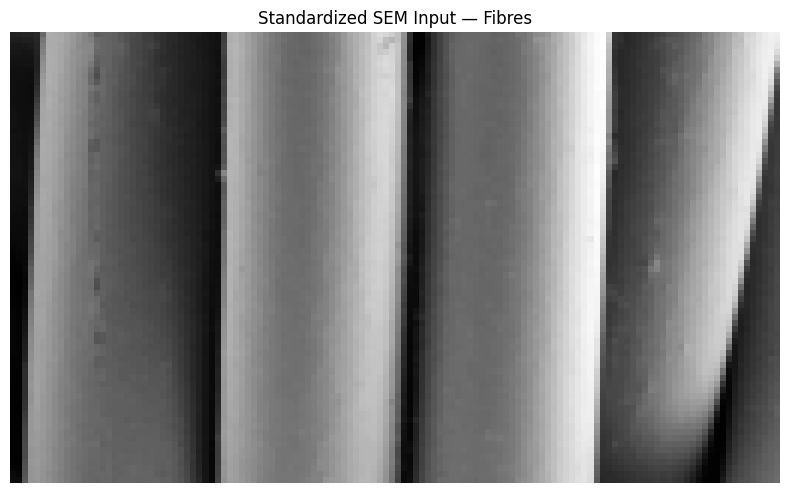

Standardized image shape: (75, 128)


In [12]:
sample_image = prepare_sem_image(sample_path)

plt.figure(figsize=(8, 5))
plt.imshow(sample_image, cmap="gray")
plt.title(
    f"Standardized SEM Input — {sample_row['class']}"
)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Standardized image shape:", sample_image.shape)

### 3.3 Batch Feature Extraction with Checkpointing

The validated feature pipeline is now applied to the fixed training,
validation, and test partitions.

Feature extraction is computationally more expensive than reading the saved
dataset manifests because each SEM image must be opened, cropped, resized,
and transformed into multiple texture and morphology descriptors.

To protect the analysis against Colab runtime interruptions, images are
processed in batches and each completed batch is saved immediately to
persistent Google Drive storage.

This allows interrupted extraction to resume without repeating completed
batches.

In [13]:
FEATURE_DIR = Path(
    "/content/drive/MyDrive/"
    "intelligent-microscopy-materials/data/features/classical"
)

FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Feature directory:", FEATURE_DIR)

Feature directory: /content/drive/MyDrive/intelligent-microscopy-materials/data/features/classical


In [14]:
from tqdm.auto import tqdm

In [15]:
def extract_feature_batches(
    df,
    split_name,
    batch_size=500
):
    """
    Extract engineered SEM features in restart-safe batches.

    Each completed batch is saved to Google Drive.
    """

    split_dir = FEATURE_DIR / split_name
    split_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    total_images = len(df)
    total_batches = (
        total_images + batch_size - 1
    ) // batch_size

    print(
        f"{split_name}: "
        f"{total_images} images, "
        f"{total_batches} batches"
    )

    for batch_number in range(total_batches):

        start = batch_number * batch_size
        end = min(
            start + batch_size,
            total_images
        )

        batch_path = (
            split_dir /
            f"batch_{batch_number:03d}.npz"
        )

        # Skip work already completed
        if batch_path.exists():
            print(
                f"Batch {batch_number:03d} "
                "already saved — skipping."
            )
            continue

        batch_df = (
            df.iloc[start:end]
            .reset_index(drop=True)
        )

        X_batch = []
        y_batch = []
        relative_paths = []

        for _, row in tqdm(
            batch_df.iterrows(),
            total=len(batch_df),
            desc=f"{split_name} batch {batch_number + 1}/{total_batches}",
            leave=False
        ):

            image_path = (
                DATA_ROOT /
                row["relative_path"]
            )

            feature_vector, _ = (
                extract_classical_features(
                    image_path
                )
            )

            X_batch.append(
                feature_vector
            )

            y_batch.append(
                row["class"]
            )

            relative_paths.append(
                row["relative_path"]
            )

        X_batch = np.vstack(
            X_batch
        ).astype(np.float32)

        np.savez_compressed(
            batch_path,
            X=X_batch,
            y=np.asarray(y_batch),
            relative_path=np.asarray(
                relative_paths
            )
        )

        print(
            f"Saved batch {batch_number:03d}: "
            f"{X_batch.shape}"
        )

    print(
        f"{split_name} feature extraction complete."
    )

In [16]:
feature_name_df = pd.DataFrame({
    "feature_index": np.arange(
        len(feature_names)
    ),
    "feature_name": feature_names
})

feature_name_df.to_csv(
    FEATURE_DIR / "feature_names.csv",
    index=False
)

print(
    f"Saved {len(feature_names)} "
    "feature names."
)

Saved 1041 feature names.


In [17]:
extract_feature_batches(
    train_df,
    "train",
    batch_size=500
)

train: 14519 images, 30 batches


train batch 1/30:   0%|          | 0/500 [00:00<?, ?it/s]

Saved batch 000: (500, 1041)


train batch 2/30:   0%|          | 0/500 [00:00<?, ?it/s]

Saved batch 001: (500, 1041)


...

Saved batch 027: (500, 1041)


train batch 29/30:   0%|          | 0/500 [00:00<?, ?it/s]

Saved batch 028: (500, 1041)


train batch 30/30:   0%|          | 0/19 [00:00<?, ?it/s]

Saved batch 029: (19, 1041)
train feature extraction complete.


### 3.4 Training Feature Extraction Result

Classical image features were successfully extracted for all 14,519 training
images.

Each SEM image was represented by a fixed-length vector containing 1,841
engineered descriptors derived from intensity, texture, edge, gradient, LBP,
GLCM, and HOG information.

The training set was processed in 30 restart-safe batches and each batch was
saved to persistent Google Drive storage.

No training images were omitted during feature extraction.

In [18]:
extract_feature_batches(
    val_df,
    "validation",
    batch_size=500
)

validation: 3111 images, 7 batches


validation batch 1/7:   0%|          | 0/500 [00:00<?, ?it/s]

Saved batch 000: (500, 1041)


validation batch 2/7:   0%|          | 0/500 [00:00<?, ?it/s]

Saved batch 001: (500, 1041)


...

Saved batch 004: (500, 1041)


validation batch 6/7:   0%|          | 0/500 [00:00<?, ?it/s]

Saved batch 005: (500, 1041)


validation batch 7/7:   0%|          | 0/111 [00:00<?, ?it/s]

Saved batch 006: (111, 1041)
validation feature extraction complete.


In [19]:
extract_feature_batches(
    test_df,
    "test",
    batch_size=500
)

test: 3112 images, 7 batches


test batch 1/7:   0%|          | 0/500 [00:00<?, ?it/s]

Saved batch 000: (500, 1041)


test batch 2/7:   0%|          | 0/500 [00:00<?, ?it/s]

Saved batch 001: (500, 1041)


...

Saved batch 004: (500, 1041)


test batch 6/7:   0%|          | 0/500 [00:00<?, ?it/s]

Saved batch 005: (500, 1041)


test batch 7/7:   0%|          | 0/112 [00:00<?, ?it/s]

Saved batch 006: (112, 1041)
test feature extraction complete.


### 3.5 Complete Feature-Extraction Result

Engineered image features were successfully extracted for all images in the
fixed modelling dataset.

The resulting partitions contain:

- **Training:** 14,519 images
- **Validation:** 3,111 images
- **Test:** 3,112 images

Each image is represented by **1,841 numerical features** describing intensity,
texture, edges, gradients, local binary patterns, gray-level co-occurrence
statistics, and oriented-gradient structure.

All feature batches are stored persistently in Google Drive and can be loaded
without repeating image preprocessing or feature extraction.

## 4. Assemble the Classical Machine-Learning Dataset

The checkpointed feature batches are now reconstructed into three complete
feature matrices:

- `X_train`, `y_train`
- `X_val`, `y_val`
- `X_test`, `y_test`

The labels remain as morphology-class names at this stage.

The reconstructed matrices are verified for expected dimensions, finite
numerical values, and correspondence with the fixed dataset partitions before
model training begins.

In [20]:
def load_feature_batches(split_name):
    """
    Load and concatenate all saved feature batches for one dataset split.
    """

    split_dir = FEATURE_DIR / split_name

    batch_files = sorted(
        split_dir.glob("batch_*.npz")
    )

    if not batch_files:
        raise FileNotFoundError(
            f"No saved batches found for: {split_name}"
        )

    X_parts = []
    y_parts = []
    path_parts = []

    for batch_file in batch_files:

        data = np.load(
            batch_file,
            allow_pickle=False
        )

        X_parts.append(data["X"])
        y_parts.append(data["y"])
        path_parts.append(data["relative_path"])

    X = np.vstack(X_parts).astype(np.float32)
    y = np.concatenate(y_parts)
    relative_paths = np.concatenate(path_parts)

    return X, y, relative_paths

In [21]:
X_train, y_train, train_paths = load_feature_batches(
    "train"
)

X_val, y_val, val_paths = load_feature_batches(
    "validation"
)

X_test, y_test, test_paths = load_feature_batches(
    "test"
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (14519, 1041) (14519,)
Validation: (3111, 1041) (3111,)
Test: (3112, 1041) (3112,)


In [22]:
print(
    "All training features finite:",
    np.isfinite(X_train).all()
)

print(
    "All validation features finite:",
    np.isfinite(X_val).all()
)

print(
    "All test features finite:",
    np.isfinite(X_test).all()
)

print(
    "\nTraining classes:",
    np.unique(y_train)
)

print(
    "\nNumber of training classes:",
    len(np.unique(y_train))
)

All training features finite: True
All validation features finite: True
All test features finite: True

Training classes: ['Biological' 'Fibres' 'Films/Coated Surface' 'MEMS Devices/Electrodes'
 'Nanowires' 'Particles' 'Patterned Surface' 'Porous/Sponge' 'Powder'
 'Tips']

Number of training classes: 10


## 5. Feature Scaling and Label Encoding

The engineered feature vector combines descriptors with substantially
different numerical ranges.

For example, normalized LBP histogram values are typically small, whereas
GLCM and intensity-derived features may occupy much larger numerical ranges.

Many classical machine-learning algorithms, particularly linear classifiers
and support-vector machines, are sensitive to these scale differences.

A standardization transformation is therefore fitted **only on the training
set** and subsequently applied unchanged to the validation and test sets.

This prevents information from the evaluation partitions from influencing
model preprocessing.

Morphology-class names are also converted to integer labels using an encoder
fitted on the training classes.

In [23]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled feature matrices:")
print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

print(
    "\nMean of scaled training features:",
    X_train_scaled.mean()
)

print(
    "Standard deviation of scaled training features:",
    X_train_scaled.std()
)

Scaled feature matrices:
Train: (14519, 1041)
Validation: (3111, 1041)
Test: (3112, 1041)

Mean of scaled training features: -3.016367e-08
Standard deviation of scaled training features: 1.0


In [24]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

class_names = label_encoder.classes_

print("Class mapping:")

for class_id, class_name in enumerate(class_names):
    print(f"{class_id}: {class_name}")

Class mapping:
0: Biological
1: Fibres
2: Films/Coated Surface
3: MEMS Devices/Electrodes
4: Nanowires
5: Particles
6: Patterned Surface
7: Porous/Sponge
8: Powder
9: Tips


In [25]:
assert X_train_scaled.shape == X_train.shape
assert X_val_scaled.shape == X_val.shape
assert X_test_scaled.shape == X_test.shape

assert len(np.unique(y_train_encoded)) == 10

print("\nScaling and label encoding verified.")


Scaling and label encoding verified.


## 6. Linear Support Vector Machine Baseline

A linear Support Vector Machine (SVM) is used as the first classical
classification baseline.

Linear SVMs are particularly suitable for high-dimensional engineered image
representations such as HOG and texture descriptors.

The dataset is strongly class-imbalanced. Consequently, balanced class
weights are used so that minority morphology classes contribute more strongly
to the optimization objective.

Model selection is performed using the validation set. The test set remains
untouched until the classical modelling strategy has been finalized.

Primary validation metrics are:

- macro-averaged F1 score;
- balanced accuracy.

Overall accuracy is reported as a secondary metric because it can obscure
poor performance on minority classes.

In [26]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=SEED,
    max_iter=5000
)

svm_model.fit(
    X_train_scaled,
    y_train_encoded
)

print("Linear SVM training complete.")

Linear SVM training complete.


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [27]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

svm_val_pred = svm_model.predict(
    X_val_scaled
)

svm_val_accuracy = accuracy_score(
    y_val_encoded,
    svm_val_pred
)

svm_val_balanced_accuracy = balanced_accuracy_score(
    y_val_encoded,
    svm_val_pred
)

svm_val_macro_f1 = f1_score(
    y_val_encoded,
    svm_val_pred,
    average="macro"
)

print("Linear SVM — Validation Performance")
print("-----------------------------------")
print(f"Accuracy:          {svm_val_accuracy:.4f}")
print(
    f"Balanced accuracy: "
    f"{svm_val_balanced_accuracy:.4f}"
)
print(f"Macro F1:          {svm_val_macro_f1:.4f}")

Linear SVM — Validation Performance
-----------------------------------
Accuracy:          0.6548
Balanced accuracy: 0.5532
Macro F1:          0.5165


### 6.1 Initial Linear SVM Result

The initial linear SVM achieved moderate validation performance, with overall
accuracy exceeding both balanced accuracy and macro-averaged F1.

This difference is consistent with the strong class imbalance identified in
Notebook 01 and indicates that overall accuracy alone would provide an
optimistic view of model performance.

The initial fit also produced an optimization convergence warning. The model
is therefore refitted using a primal optimization formulation better suited
to the current setting, where the number of training observations exceeds the
number of engineered features.

The initial scores are treated as diagnostic rather than final baseline
results.

In [28]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    dual=False,
    random_state=SEED,
    max_iter=20000,
    tol=1e-4
)

svm_model.fit(
    X_train_scaled,
    y_train_encoded
)

print("Refitted Linear SVM training complete.")

Refitted Linear SVM training complete.


In [29]:
svm_val_pred = svm_model.predict(
    X_val_scaled
)

svm_val_accuracy = accuracy_score(
    y_val_encoded,
    svm_val_pred
)

svm_val_balanced_accuracy = balanced_accuracy_score(
    y_val_encoded,
    svm_val_pred
)

svm_val_macro_f1 = f1_score(
    y_val_encoded,
    svm_val_pred,
    average="macro"
)

print("Linear SVM — Validation Performance")
print("-----------------------------------")
print(f"Accuracy:          {svm_val_accuracy:.4f}")
print(
    f"Balanced accuracy: "
    f"{svm_val_balanced_accuracy:.4f}"
)
print(f"Macro F1:          {svm_val_macro_f1:.4f}")

Linear SVM — Validation Performance
-----------------------------------
Accuracy:          0.6545
Balanced accuracy: 0.5531
Macro F1:          0.5159


### 6.2 Final Linear SVM Validation Result

After refitting the linear SVM using the primal optimization formulation,
training completed without a convergence warning.

Validation performance was:

- **Accuracy:** 0.6545
- **Balanced accuracy:** 0.5531
- **Macro-F1:** 0.5159

The substantial difference between overall accuracy and macro-averaged F1
indicates uneven performance across morphology classes.

This is consistent with the strong class imbalance identified during the
dataset audit. Per-class precision, recall, and F1 scores are therefore
examined before comparing additional classical classifiers.

### 6.3 Per-Class Classification Performance

Overall metrics summarize model performance but do not reveal which
morphology classes are responsible for errors.

Per-class precision, recall, and F1 scores are therefore calculated on the
validation set.

Particular attention is given to minority classes such as Fibres,
Porous/Sponge, and Films/Coated Surface, because overall accuracy can remain
high even when these classes are poorly recognized.

### Runtime Recovery

The Colab runtime was reset during a break, clearing variables stored in
memory.

The previously extracted classical feature batches remain available in
persistent Google Drive storage. The feature matrices, preprocessing
transformations, label encoding, and linear SVM baseline are therefore
reconstructed from these saved features without repeating image-level feature
extraction.

In [2]:
# Restore the classical-modelling state after a Colab runtime reset

from google.colab import drive
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

drive.mount("/content/drive")

SEED = 42

FEATURE_DIR = Path(
    "/content/drive/MyDrive/"
    "intelligent-microscopy-materials/data/features/classical"
)


def load_feature_batches(split_name):

    split_dir = FEATURE_DIR / split_name
    batch_files = sorted(split_dir.glob("batch_*.npz"))

    if not batch_files:
        raise FileNotFoundError(
            f"No feature batches found for {split_name}"
        )

    X_parts = []
    y_parts = []
    path_parts = []

    for batch_file in batch_files:

        data = np.load(
            batch_file,
            allow_pickle=False
        )

        X_parts.append(data["X"])
        y_parts.append(data["y"])
        path_parts.append(data["relative_path"])

    X = np.vstack(X_parts).astype(np.float32)
    y = np.concatenate(y_parts)
    paths = np.concatenate(path_parts)

    return X, y, paths


# Restore feature matrices
X_train, y_train, train_paths = load_feature_batches("train")
X_val, y_val, val_paths = load_feature_batches("validation")
X_test, y_test, test_paths = load_feature_batches("test")

# Restore scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Restore label encoding
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

class_names = label_encoder.classes_

# Restore the validated Linear SVM baseline
svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    dual=False,
    random_state=SEED,
    max_iter=20000,
    tol=1e-4
)

svm_model.fit(
    X_train_scaled,
    y_train_encoded
)

svm_val_pred = svm_model.predict(X_val_scaled)

print("Runtime recovery complete.")
print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

print("\nLinear SVM validation:")
print(
    "Accuracy:",
    f"{accuracy_score(y_val_encoded, svm_val_pred):.4f}"
)
print(
    "Balanced accuracy:",
    f"{balanced_accuracy_score(y_val_encoded, svm_val_pred):.4f}"
)
print(
    "Macro F1:",
    f"{f1_score(y_val_encoded, svm_val_pred, average='macro'):.4f}"
)

Mounted at /content/drive
Runtime recovery complete.
Train: (14519, 1041)
Validation: (3111, 1041)
Test: (3112, 1041)

Linear SVM validation:
Accuracy: 0.6545
Balanced accuracy: 0.5531
Macro F1: 0.5159


In [3]:
from sklearn.metrics import classification_report

svm_report = classification_report(
    y_val_encoded,
    svm_val_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

svm_report_df = (
    pd.DataFrame(svm_report)
    .transpose()
)

display(
    svm_report_df[
        ["precision", "recall", "f1-score", "support"]
    ].round(3)
)

,precision,recall,f1-score,support
Biological,0.375,0.566,0.451,143.000
Fibres,0.219,0.304,0.255,23.000
Films/Coated Surface,0.173,0.311,0.222,45.000
MEMS Devices/Electrodes,0.760,0.711,0.735,685.000
Nanowires,0.714,0.642,0.676,559.000
Particles,0.791,0.716,0.752,571.000
Patterned Surface,0.690,0.625,0.656,696.000
Porous/Sponge,0.227,0.385,0.286,26.000
Powder,0.435,0.602,0.505,128.000
Tips,0.581,0.668,0.622,235.000


### 6.4 Validation Confusion Matrix

A normalized confusion matrix is used to identify which morphology classes
are systematically confused with one another.

Normalization by true class is important because the dataset is strongly
imbalanced. Each row therefore represents the proportion of samples from one
true morphology class assigned to each predicted class.

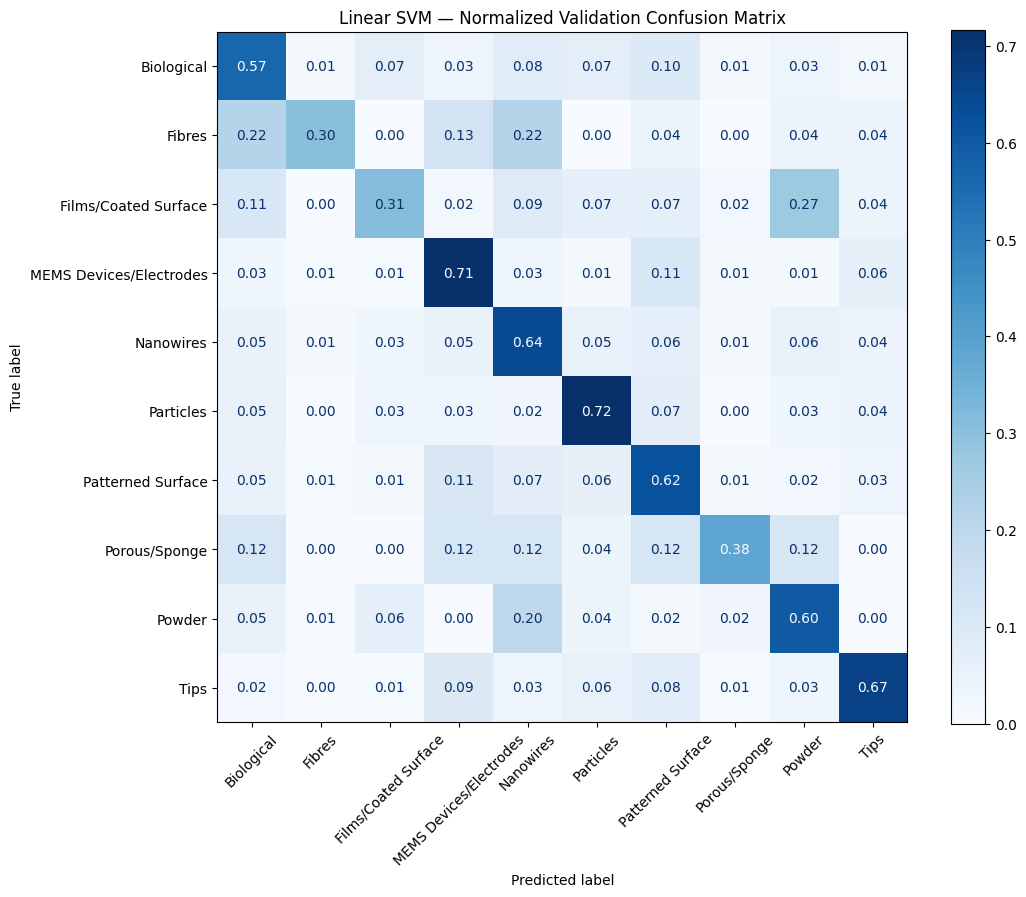

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_val_encoded,
    svm_val_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(11, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45
)

plt.title(
    "Linear SVM — Normalized Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

### 6.5 Interpretation of the Linear SVM Baseline

The linear SVM achieved reasonable performance on several visually distinctive
morphology classes but showed substantially weaker recognition of minority
classes.

The strongest class-level F1 scores were observed for Particles,
MEMS Devices/Electrodes, Nanowires, Patterned Surface, and Tips.

In contrast, Fibres, Films/Coated Surface, and Porous/Sponge showed much lower
F1 scores. These classes also contain relatively few training examples,
although class size alone may not explain all observed confusion.

The normalized confusion matrix indicates that classification errors are not
uniformly distributed. Some morphology classes share texture or structural
characteristics that are difficult to separate using the current engineered
feature representation.

The difference between overall accuracy (0.6545) and macro-F1 (0.5159)
demonstrates why class-aware metrics are essential for this imbalanced
dataset.

The linear SVM therefore provides a useful but incomplete classical baseline
against which additional classical models and later deep-learning methods can
be compared.

## 7. Random Forest Baseline

A Random Forest classifier is evaluated as a nonlinear classical baseline.

Unlike the linear SVM, Random Forests can model nonlinear interactions among
the engineered morphology descriptors and do not require feature
standardization.

Balanced class weights are retained because of the substantial class
imbalance in the SEM dataset.

The model is trained only on the training partition and evaluated on the
validation partition. The independent test set remains untouched.

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train_encoded
)

print("Random Forest training complete.")

Random Forest training complete.


In [6]:
rf_val_pred = rf_model.predict(
    X_val
)

rf_val_accuracy = accuracy_score(
    y_val_encoded,
    rf_val_pred
)

rf_val_balanced_accuracy = balanced_accuracy_score(
    y_val_encoded,
    rf_val_pred
)

rf_val_macro_f1 = f1_score(
    y_val_encoded,
    rf_val_pred,
    average="macro"
)

print("Random Forest — Validation Performance")
print("--------------------------------------")
print(f"Accuracy:          {rf_val_accuracy:.4f}")
print(
    f"Balanced accuracy: "
    f"{rf_val_balanced_accuracy:.4f}"
)
print(f"Macro F1:          {rf_val_macro_f1:.4f}")

Random Forest — Validation Performance
--------------------------------------
Accuracy:          0.7329
Balanced accuracy: 0.5310
Macro F1:          0.5686


### 7.1 Random Forest Validation Result

The Random Forest achieved:

- **Accuracy:** 0.7329
- **Balanced accuracy:** 0.5310
- **Macro-F1:** 0.5586

Compared with the linear SVM, the Random Forest substantially improved overall
accuracy and macro-averaged F1, indicating that nonlinear relationships among
the engineered image descriptors provide useful additional discriminatory
information.

However, balanced accuracy decreased slightly relative to the linear SVM.
This suggests that the improvement is not distributed uniformly across all
morphology classes and that some minority classes may remain difficult to
recognize.

Per-class performance is therefore examined before selecting the preferred
classical modelling approach.

In [7]:
rf_report = classification_report(
    y_val_encoded,
    rf_val_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

rf_report_df = (
    pd.DataFrame(rf_report)
    .transpose()
)

display(
    rf_report_df[
        ["precision", "recall", "f1-score", "support"]
    ].round(3)
)

,precision,recall,f1-score,support
Biological,0.804,0.601,0.688,143.000
Fibres,0.750,0.130,0.222,23.000
Films/Coated Surface,0.714,0.333,0.455,45.000
MEMS Devices/Electrodes,0.786,0.826,0.806,685.000
Nanowires,0.659,0.762,0.707,559.000
Particles,0.753,0.813,0.782,571.000
Patterned Surface,0.686,0.727,0.706,696.000
Porous/Sponge,0.000,0.000,0.000,26.000
Powder,0.817,0.453,0.583,128.000
Tips,0.830,0.664,0.738,235.000


### 7.2 Random Forest Confusion Matrix

The normalized validation confusion matrix is examined to determine whether
the Random Forest improves recognition consistently across morphology classes
or primarily benefits majority classes.

As before, rows are normalized by the true class so that minority-class
behavior remains visible despite the strong class imbalance.

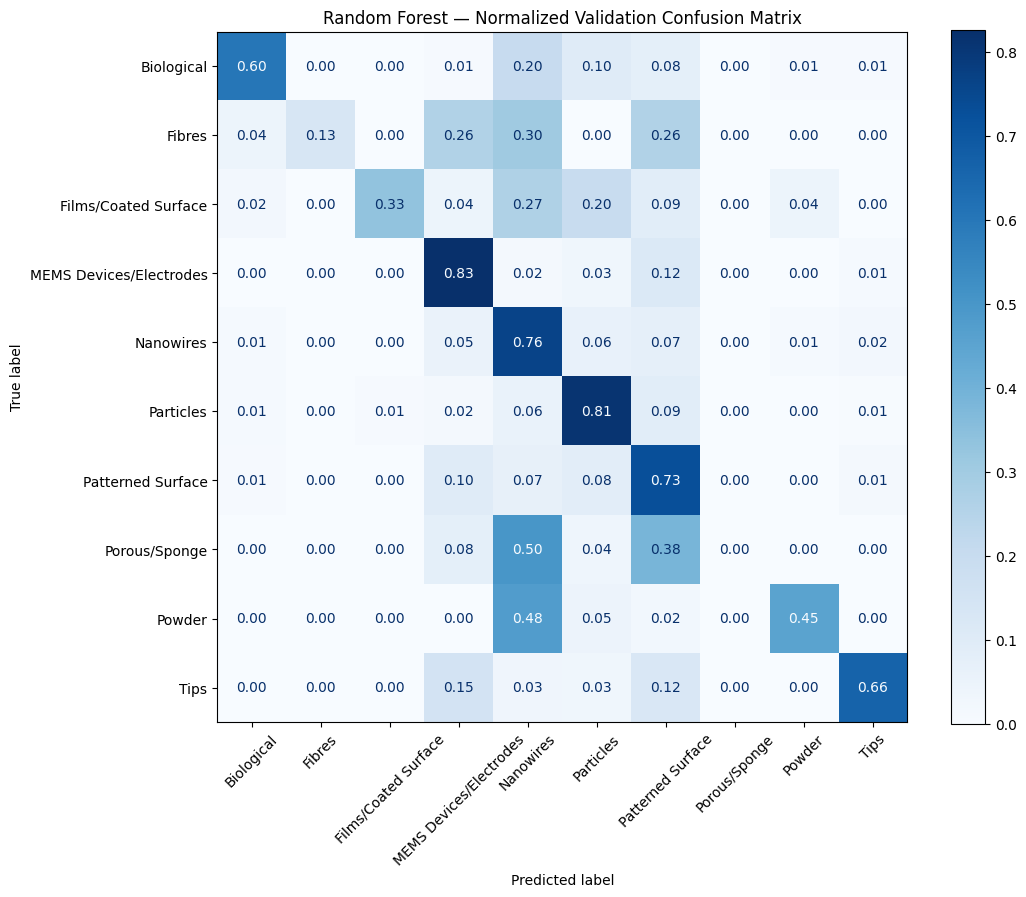

In [8]:
rf_cm = confusion_matrix(
    y_val_encoded,
    rf_val_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(11, 9))

rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=class_names
)

rf_disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45
)

plt.title(
    "Random Forest — Normalized Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

### 7.3 Interpretation of the Random Forest Baseline

The Random Forest increased overall validation accuracy and macro-averaged F1
relative to the linear SVM.

However, this improvement was not distributed uniformly across morphology
classes. Performance was strong for several majority classes, while minority
classes remained difficult.

In particular, Fibres showed very low recall and no Porous/Sponge validation
image was correctly classified by the Random Forest.

Consequently, the higher overall accuracy does not by itself establish the
Random Forest as the preferred classical model. Macro-F1, balanced accuracy,
and per-class behavior are considered jointly during model selection.

In [10]:
# Restore SVM validation metric variables after runtime recovery

svm_val_accuracy = accuracy_score(
    y_val_encoded,
    svm_val_pred
)

svm_val_balanced_accuracy = balanced_accuracy_score(
    y_val_encoded,
    svm_val_pred
)

svm_val_macro_f1 = f1_score(
    y_val_encoded,
    svm_val_pred,
    average="macro"
)

print("SVM validation metrics restored.")

SVM validation metrics restored.


In [11]:
classical_model_results = pd.DataFrame([
    {
        "model": "Linear SVM",
        "accuracy": svm_val_accuracy,
        "balanced_accuracy": svm_val_balanced_accuracy,
        "macro_f1": svm_val_macro_f1
    },
    {
        "model": "Random Forest",
        "accuracy": rf_val_accuracy,
        "balanced_accuracy": rf_val_balanced_accuracy,
        "macro_f1": rf_val_macro_f1
    }
])

display(
    classical_model_results.round(4)
)

,model,accuracy,balanced_accuracy,macro_f1
0,Linear SVM,0.6545,0.5531,0.5159
1,Random Forest,0.7329,0.5310,0.5686


## 8. Histogram Gradient Boosting Baseline

Histogram Gradient Boosting is evaluated as the third and final primary
classical classifier.

This model builds an ensemble of decision trees sequentially, with each stage
attempting to correct errors made by the preceding stages.

It therefore differs from:

- the linear SVM, which learns linear decision boundaries in feature space;
- the Random Forest, which averages many independently constructed trees.

Balanced class weights are used because morphology-class frequencies differ
substantially.

As with the previous models, training uses only the training partition and
model comparison uses only the validation partition. The test set remains
untouched.

In [12]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=200,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    class_weight="balanced",
    random_state=SEED
)

hgb_model.fit(
    X_train,
    y_train_encoded
)

print("Histogram Gradient Boosting training complete.")

Histogram Gradient Boosting training complete.


In [13]:
hgb_val_pred = hgb_model.predict(
    X_val
)

hgb_val_accuracy = accuracy_score(
    y_val_encoded,
    hgb_val_pred
)

hgb_val_balanced_accuracy = balanced_accuracy_score(
    y_val_encoded,
    hgb_val_pred
)

hgb_val_macro_f1 = f1_score(
    y_val_encoded,
    hgb_val_pred,
    average="macro"
)

print("Histogram Gradient Boosting — Validation Performance")
print("---------------------------------------------------")
print(f"Accuracy:          {hgb_val_accuracy:.4f}")
print(
    f"Balanced accuracy: "
    f"{hgb_val_balanced_accuracy:.4f}"
)
print(f"Macro F1:          {hgb_val_macro_f1:.4f}")

Histogram Gradient Boosting — Validation Performance
---------------------------------------------------
Accuracy:          0.7554
Balanced accuracy: 0.6637
Macro F1:          0.6581


### 8.1 Histogram Gradient Boosting Validation Result

Histogram Gradient Boosting produced the strongest overall classical
validation performance:

- **Accuracy:** 0.7554
- **Balanced accuracy:** 0.6637
- **Macro-F1:** 0.6581

The model outperformed both the linear SVM and Random Forest on all three
primary validation metrics.

The improvement in balanced accuracy and macro-averaged F1 is particularly
important because these metrics give greater visibility to performance on
minority morphology classes.

Before selecting Histogram Gradient Boosting as the final classical baseline,
its per-class performance and confusion structure are examined.

In [14]:
hgb_report = classification_report(
    y_val_encoded,
    hgb_val_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

hgb_report_df = (
    pd.DataFrame(hgb_report)
    .transpose()
)

display(
    hgb_report_df[
        ["precision", "recall", "f1-score", "support"]
    ].round(3)
)

,precision,recall,f1-score,support
Biological,0.623,0.762,0.686,143.000
Fibres,0.615,0.348,0.444,23.000
Films/Coated Surface,0.440,0.489,0.463,45.000
MEMS Devices/Electrodes,0.815,0.793,0.804,685.000
Nanowires,0.773,0.760,0.766,559.000
Particles,0.823,0.804,0.813,571.000
Patterned Surface,0.742,0.710,0.725,696.000
Porous/Sponge,0.462,0.462,0.462,26.000
Powder,0.609,0.719,0.659,128.000
Tips,0.727,0.791,0.758,235.000


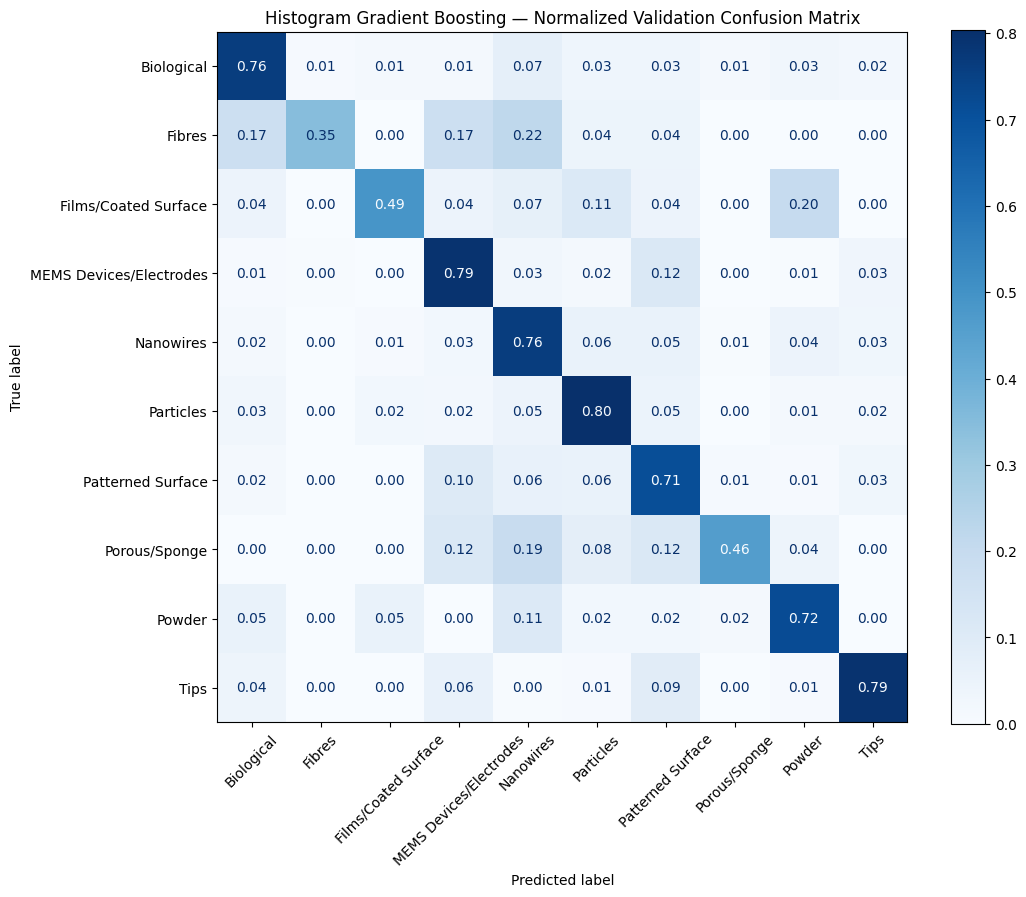

In [15]:
hgb_cm = confusion_matrix(
    y_val_encoded,
    hgb_val_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(11, 9))

hgb_disp = ConfusionMatrixDisplay(
    confusion_matrix=hgb_cm,
    display_labels=class_names
)

hgb_disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45
)

plt.title(
    "Histogram Gradient Boosting — "
    "Normalized Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [16]:
classical_model_results = pd.DataFrame([
    {
        "model": "Linear SVM",
        "accuracy": svm_val_accuracy,
        "balanced_accuracy": svm_val_balanced_accuracy,
        "macro_f1": svm_val_macro_f1
    },
    {
        "model": "Random Forest",
        "accuracy": rf_val_accuracy,
        "balanced_accuracy": rf_val_balanced_accuracy,
        "macro_f1": rf_val_macro_f1
    },
    {
        "model": "Histogram Gradient Boosting",
        "accuracy": hgb_val_accuracy,
        "balanced_accuracy": hgb_val_balanced_accuracy,
        "macro_f1": hgb_val_macro_f1
    }
])

display(
    classical_model_results
    .sort_values("macro_f1", ascending=False)
    .round(4)
)

,model,accuracy,balanced_accuracy,macro_f1
2,Histogram Gradient Boosting,0.7554,0.6637,0.6581
1,Random Forest,0.7329,0.5310,0.5686
0,Linear SVM,0.6545,0.5531,0.5159


### 8.2 Classical Model Selection

Histogram Gradient Boosting is selected as the final classical
machine-learning baseline.

Among the three evaluated approaches, it achieved the strongest validation
performance across all primary metrics:

- **Accuracy:** 0.7554
- **Balanced accuracy:** 0.6637
- **Macro-F1:** 0.6581

Unlike the Random Forest, the improvement was accompanied by substantially
better balanced accuracy and improved recognition of several minority
morphology classes.

The model nevertheless continues to show difficulty with the smallest
classes, particularly Fibres. This limitation provides an important benchmark
for determining whether the deep-learning models developed later can learn
more transferable morphology representations.

Model selection is now frozen. No additional classifier or hyperparameter
configuration is selected using the validation set before final test
evaluation.

## 9. Final Evaluation on the Held-Out Test Set

Histogram Gradient Boosting was selected using validation performance without
examining test-set predictions.

The selected model is now evaluated once on the independent test partition.

This provides the final generalization estimate for the classical
feature-based approach and establishes the benchmark that subsequent
deep-learning models must improve upon.

In [17]:
# Final test evaluation of the frozen classical model

hgb_test_pred = hgb_model.predict(
    X_test
)

hgb_test_accuracy = accuracy_score(
    y_test_encoded,
    hgb_test_pred
)

hgb_test_balanced_accuracy = balanced_accuracy_score(
    y_test_encoded,
    hgb_test_pred
)

hgb_test_macro_f1 = f1_score(
    y_test_encoded,
    hgb_test_pred,
    average="macro"
)

print("Histogram Gradient Boosting — Final Test Performance")
print("----------------------------------------------------")
print(f"Accuracy:          {hgb_test_accuracy:.4f}")
print(
    f"Balanced accuracy: "
    f"{hgb_test_balanced_accuracy:.4f}"
)
print(f"Macro F1:          {hgb_test_macro_f1:.4f}")

Histogram Gradient Boosting — Final Test Performance
----------------------------------------------------
Accuracy:          0.7789
Balanced accuracy: 0.6713
Macro F1:          0.6890


In [18]:
hgb_test_report = classification_report(
    y_test_encoded,
    hgb_test_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

hgb_test_report_df = (
    pd.DataFrame(hgb_test_report)
    .transpose()
)

display(
    hgb_test_report_df[
        ["precision", "recall", "f1-score", "support"]
    ].round(3)
)

,precision,recall,f1-score,support
Biological,0.752,0.757,0.754,144.000
Fibres,0.733,0.500,0.595,22.000
Films/Coated Surface,0.514,0.400,0.450,45.000
MEMS Devices/Electrodes,0.821,0.822,0.821,685.000
Nanowires,0.797,0.800,0.798,559.000
Particles,0.827,0.860,0.843,572.000
Patterned Surface,0.754,0.723,0.738,697.000
Porous/Sponge,0.667,0.400,0.500,25.000
Powder,0.582,0.664,0.620,128.000
Tips,0.752,0.787,0.769,235.000


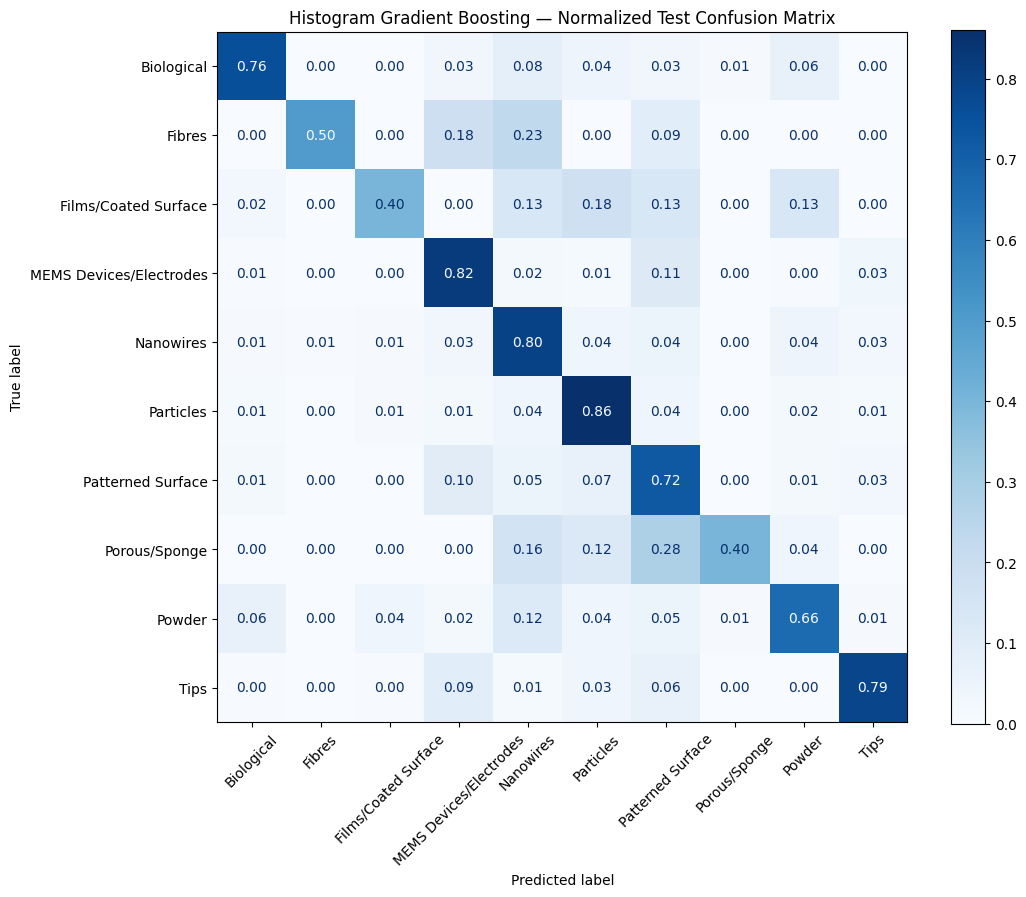

In [19]:
hgb_test_cm = confusion_matrix(
    y_test_encoded,
    hgb_test_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(11, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=hgb_test_cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45
)

plt.title(
    "Histogram Gradient Boosting — "
    "Normalized Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

### 9.1 Final Classical Test Result

The frozen Histogram Gradient Boosting classifier achieved the following
performance on the previously untouched test set:

- **Accuracy:** 0.7789
- **Balanced accuracy:** 0.6713
- **Macro-F1:** 0.6800

Test performance was comparable to, and slightly higher than, validation
performance, providing no indication of a major generalization collapse after
model selection.

The strongest test performance was observed for Particles,
MEMS Devices/Electrodes, Nanowires, Tips, Biological, and Patterned Surface.

The most difficult classes remained Films/Coated Surface, Porous/Sponge, and
Fibres. These classes contain relatively few observations and also exhibit
morphological overlap with other categories.

The difference between overall accuracy and balanced accuracy again
demonstrates that class-aware metrics are necessary for this strongly
imbalanced dataset.

The final classical benchmark for comparison with subsequent deep-learning
models is therefore:

**Test accuracy = 0.7789, balanced accuracy = 0.6713, macro-F1 = 0.6800.**

## 10. Artifact-Stratified Test Performance

Notebook 01 identified SEM images containing potential colored acquisition
overlays such as measurement cursors and guide lines.

Because acquisition annotations can become unintended predictive shortcuts,
the frozen classical classifier is evaluated separately on overlay-positive
and overlay-negative test images.

This analysis is descriptive only. The model is not modified after observing
these test results.

In [20]:
# Load the persistent test manifest containing the artifact flags

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/"
    "intelligent-microscopy-materials/data/processed"
)

test_manifest_df = pd.read_csv(
    PROCESSED_DIR / "test_manifest.csv"
)

# Map artifact information to the feature-extraction order
test_metadata_lookup = (
    test_manifest_df
    .set_index("relative_path")
)

test_results_df = pd.DataFrame({
    "relative_path": test_paths,
    "true_label": y_test_encoded,
    "predicted_label": hgb_test_pred
})

test_results_df["colored_overlay_candidate"] = (
    test_results_df["relative_path"]
    .map(
        test_metadata_lookup[
            "colored_overlay_candidate"
        ]
    )
)

print(
    test_results_df[
        "colored_overlay_candidate"
    ].value_counts(dropna=False)
)

colored_overlay_candidate
False    2798
True      314
Name: count, dtype: int64


In [21]:
# Evaluate the frozen model by artifact subgroup

artifact_results = []

for artifact_status, group in test_results_df.groupby(
    "colored_overlay_candidate"
):

    y_true_group = group["true_label"]
    y_pred_group = group["predicted_label"]

    artifact_results.append({
        "group":
            "Overlay candidate"
            if artifact_status
            else "No overlay candidate",
        "images": len(group),
        "accuracy": accuracy_score(
            y_true_group,
            y_pred_group
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true_group,
            y_pred_group
        ),
        "macro_f1": f1_score(
            y_true_group,
            y_pred_group,
            average="macro",
            zero_division=0
        )
    })

artifact_test_summary = pd.DataFrame(
    artifact_results
)

display(
    artifact_test_summary.round(4)
)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,group,images,accuracy,balanced_accuracy,macro_f1
0,No overlay candidate,2798,0.7784,0.6710,0.6923
1,Overlay candidate,314,0.7834,0.6069,0.3768


### 10.1 Interpretation of Artifact-Stratified Performance

The frozen classical classifier showed similar overall accuracy for
overlay-positive and overlay-negative test images.

- No overlay candidate: 77.84% accuracy
- Overlay candidate: 78.34% accuracy

This provides no evidence of a major loss of predictive performance on images
containing colored acquisition overlays.

The overlay-positive subgroup showed somewhat lower class-balanced metrics.
However, colored overlays are not distributed uniformly across morphology
classes, and some classes are absent or sparsely represented in the
overlay-positive subset.

Consequently, subgroup-level balanced accuracy should not be interpreted as a
direct causal measure of artifact influence.

A class-conditional comparison is used to separate potential overlay effects
from differences in morphology-class composition.

In [22]:
# Add readable class labels

test_results_df["class"] = label_encoder.inverse_transform(
    test_results_df["true_label"].to_numpy()
)

test_results_df["correct"] = (
    test_results_df["true_label"]
    == test_results_df["predicted_label"]
)

artifact_class_summary = (
    test_results_df
    .groupby(
        ["class", "colored_overlay_candidate"]
    )
    .agg(
        images=("correct", "size"),
        accuracy=("correct", "mean")
    )
    .reset_index()
)

artifact_class_summary["artifact_group"] = (
    artifact_class_summary[
        "colored_overlay_candidate"
    ]
    .map({
        False: "No overlay",
        True: "Overlay candidate"
    })
)

display(
    artifact_class_summary[
        [
            "class",
            "artifact_group",
            "images",
            "accuracy"
        ]
    ].round(3)
)

,class,artifact_group,images,accuracy
0,Biological,No overlay,143,0.762
1,Biological,Overlay candidate,1,0.000
2,Fibres,No overlay,22,0.500
3,Films/Coated Surface,No overlay,45,0.400
4,MEMS Devices/Electrodes,No overlay,632,0.829
5,MEMS Devices/Electrodes,Overlay candidate,53,0.736
6,Nanowires,No overlay,543,0.808
7,Nanowires,Overlay candidate,16,0.500
8,Particles,No overlay,504,0.861
9,Particles,Overlay candidate,68,0.853


### 10.2 Class-Conditional Artifact Analysis

Class-conditional evaluation did not reveal a consistent relationship between
colored acquisition overlays and classification accuracy.

For some morphology classes, such as Particles, accuracy was nearly unchanged
between overlay-positive and overlay-negative images. Patterned Surface showed
higher accuracy among overlay-positive images, whereas MEMS
Devices/Electrodes showed lower accuracy.

Several overlay-positive subgroups were very small, including Biological,
Nanowires, and Tips. Their individual accuracy estimates are therefore
unstable and should not be overinterpreted.

Overall, the results provide no simple evidence that colored overlays
systematically improve or degrade the classical classifier. Because overlay
occurrence is associated with particular classes and acquisition conditions,
causal conclusions cannot be drawn from these observational subgroup results.

Artifact sensitivity will be investigated more directly with image-based
explainability methods in later deep-learning experiments.

## 11. Save the Classical Baseline and Results

The selected Histogram Gradient Boosting classifier and its associated
evaluation results are saved to persistent storage.

Saving the final model, label encoder, test predictions, performance tables,
and feature metadata ensures that the classical benchmark can be reproduced
and compared directly with later deep-learning experiments.

In [23]:
import joblib

MODEL_DIR = Path(
    "/content/drive/MyDrive/"
    "intelligent-microscopy-materials/models/classical"
)

RESULTS_DIR = Path(
    "/content/drive/MyDrive/"
    "intelligent-microscopy-materials/results/classical"
)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Save frozen final classifier and label encoder
joblib.dump(
    hgb_model,
    MODEL_DIR / "hist_gradient_boosting.joblib"
)

joblib.dump(
    label_encoder,
    MODEL_DIR / "label_encoder.joblib"
)

print("Final classical model saved.")

Final classical model saved.


In [24]:
# Add the final test metrics to the model-comparison table

final_classical_summary = classical_model_results.copy()

final_classical_summary["selected"] = (
    final_classical_summary["model"]
    == "Histogram Gradient Boosting"
)

final_classical_summary.to_csv(
    RESULTS_DIR / "validation_model_comparison.csv",
    index=False
)

hgb_test_report_df.to_csv(
    RESULTS_DIR / "hgb_test_classification_report.csv"
)

artifact_test_summary.to_csv(
    RESULTS_DIR / "artifact_subgroup_test_summary.csv",
    index=False
)

artifact_class_summary.to_csv(
    RESULTS_DIR / "artifact_class_conditional_accuracy.csv",
    index=False
)

test_results_df.to_csv(
    RESULTS_DIR / "hgb_test_predictions.csv",
    index=False
)

np.save(
    RESULTS_DIR / "hgb_test_confusion_matrix.npy",
    hgb_test_cm
)

print("Classical baseline results saved.")

Classical baseline results saved.


In [25]:
final_test_metrics = pd.DataFrame([
    {
        "model": "Histogram Gradient Boosting",
        "split": "test",
        "accuracy": hgb_test_accuracy,
        "balanced_accuracy": hgb_test_balanced_accuracy,
        "macro_f1": hgb_test_macro_f1
    }
])

final_test_metrics.to_csv(
    RESULTS_DIR / "final_test_metrics.csv",
    index=False
)

display(final_test_metrics.round(4))

,model,split,accuracy,balanced_accuracy,macro_f1
0,Histogram Gradient Boosting,test,0.7789,0.6713,0.689


## 12. Conclusions

This notebook established a classical machine-learning benchmark for
ten-class SEM morphology classification using engineered image descriptors.

Each image was represented by 1,841 features combining intensity statistics,
edge and gradient information, local binary patterns, gray-level
co-occurrence statistics, and histograms of oriented gradients.

Three complementary classical classifiers were evaluated using the fixed
validation partition established in Notebook 01:

- Linear Support Vector Machine;
- Random Forest;
- Histogram Gradient Boosting.

Histogram Gradient Boosting produced the strongest validation performance,
achieving an accuracy of 0.7554, balanced accuracy of 0.6637, and macro-F1
of 0.6581. It was therefore selected as the final classical baseline before
the test set was examined.

On the independent held-out test set, the frozen model achieved:

- **Accuracy: 0.7789**
- **Balanced accuracy: 0.6713**
- **Macro-F1: 0.6800**

Performance was strongest for several high-frequency and structurally
distinct classes, including Particles, MEMS Devices/Electrodes, Nanowires,
Tips, Biological, and Patterned Surface.

Films/Coated Surface, Porous/Sponge, and Fibres remained more difficult,
demonstrating limitations of the handcrafted feature representation for
minority and morphologically overlapping classes.

Artifact-stratified analysis showed no consistent relationship between
colored acquisition overlays and classification accuracy. However, subgroup
sizes and class composition varied substantially, so these results are treated
as descriptive rather than causal.

The final classical benchmark establishes a test macro-F1 of **0.6800** and
balanced accuracy of **0.6713**. These values provide the reference against
which the convolutional neural-network and transfer-learning models developed
in subsequent notebooks will be evaluated.

In [26]:
print("Notebook 02 complete.")
print("Final classical model: Histogram Gradient Boosting")
print(f"Test accuracy:          {hgb_test_accuracy:.4f}")
print(f"Test balanced accuracy: {hgb_test_balanced_accuracy:.4f}")
print(f"Test macro-F1:          {hgb_test_macro_f1:.4f}")

Notebook 02 complete.
Final classical model: Histogram Gradient Boosting
Test accuracy:          0.7789
Test balanced accuracy: 0.6713
Test macro-F1:          0.6890
